# 📊 Phase 2b: Scaling System Exploration

**Goal**: Test 6 different scaling methods on our actual candidate features.
Use Q-Q plots to decide which scaling makes each feature most normal.
Then feed the best-scaled features into our scoring formula.

## Scaling Methods We Will Compare

| Method | Formula | Best For |
|--------|---------|----------|
| Min-Max | (x - min) / (max - min) | Bounded output [0,1], no skew correction |
| Z-Score | (x - mean) / std | Symmetric distributions |
| Log | log(x + 1) | Heavy right skew (github, skills) |
| Square Root | √x | Moderate right skew |
| Box-Cox | auto λ | Any skew, finds optimal power |
| Exponential | x^(1/3) | Left skew correction |

## Cell 1: Load Data and Extract Raw Features

Same extraction as Notebook 2, but we focus only on the continuous numeric features
that can be scaled. We exclude binary features like `open_to_work`.

In [6]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# ── Load Data ──────────────────────────────────────────────────────────
with open('sample_candidates.json') as f:
    samples = json.load(f)

# ── Skill Lists (copied from Notebook 2) ───────────────────────────────
CORE_SKILLS   = ["Python", "PyTorch", "Transformers", "NLP", "Machine Learning",
                 "TensorFlow", "Deep Learning"]
STRONG_SKILLS = ["RAG", "Fine-tuning LLMs", "LangChain", "Vector Databases",
                 "Milvus", "Computer Vision", "LoRA", "Weights & Biases",
                 "Hugging Face", "MLOps"]
NICE_SKILLS   = ["Docker", "Kubernetes", "AWS", "GCP", "SQL",
                 "Data Pipelines", "Spark", "Airflow"]
PROF_MULT = {"expert": 1.2, "advanced": 1.0, "intermediate": 0.6, "beginner": 0.2}

# ── Feature Extraction ──────────────────────────────────────────────────
rows = []
for c in samples:
    sig    = c['redrob_signals']
    skills = c['skills']

    # Raw skill score
    raw_skill = 0.0
    suspicious = 0
    for s in skills:
        name = s['name']
        prof = s['proficiency'].lower()
        endr = s['endorsements']
        effective_prof = 'beginner' if prof in ['expert','advanced'] and endr == 0 else prof
        if effective_prof in ['expert','advanced'] and endr == 0:
            suspicious += 1
        mult = PROF_MULT.get(effective_prof, 0.2)
        if   name in CORE_SKILLS:   raw_skill += 3.0 * mult
        elif name in STRONG_SKILLS: raw_skill += 2.0 * mult
        elif name in NICE_SKILLS:   raw_skill += 1.0 * mult

    assessments   = sig.get('skill_assessment_scores', {})
    assess_avg    = np.mean(list(assessments.values())) if assessments else 0.0
    github_raw    = sig.get('github_activity_score', -1)
    github_score  = max(github_raw, 0.0)
    recr_resp     = max(sig.get('recruiter_response_rate', 0), 0)
    interview     = max(sig.get('interview_completion_rate', 0), 0)
    yoe           = c['profile'].get('years_of_experience', 0)
    last_active   = pd.to_datetime(sig.get('last_active_date'))
    days_inactive = (pd.Timestamp('2026-07-01') - last_active).days

    rows.append({
        'candidate_id'  : c['candidate_id'],
        'raw_skill'     : raw_skill,
        'assess_avg'    : assess_avg,
        'github_score'  : github_score,
        'recr_resp'     : recr_resp,
        'interview'     : interview,
        'yoe'           : yoe,
        'days_inactive' : days_inactive,
        'suspicious'    : suspicious,
    })

df = pd.DataFrame(rows)

# These are the continuous features we will scale and compare
# (we exclude 'candidate_id' and binary features)
FEATURES = ['raw_skill', 'assess_avg', 'github_score',
            'recr_resp', 'interview', 'yoe', 'days_inactive']

print("Raw feature statistics:")
print(df[FEATURES].describe().round(3))

Raw feature statistics:
       raw_skill  assess_avg  github_score  recr_resp  interview     yoe  \
count     50.000      50.000         50.00     50.000     50.000  50.000   
mean       1.416      11.147         10.77      0.436      0.598   7.070   
std        1.960      23.333         17.09      0.218      0.167   3.957   
min        0.000       0.000          0.00      0.040      0.310   1.100   
25%        0.200       0.000          0.00      0.272      0.455   4.000   
50%        0.700       0.000          0.00      0.420      0.605   6.650   
75%        1.600       0.000         21.50      0.590      0.728   9.925   
max        9.800      77.600         48.50      0.910      0.900  14.500   

       days_inactive  
count         50.000  
mean         145.500  
std           74.096  
min           37.000  
25%           87.500  
50%          136.000  
75%          201.750  
max          275.000  


## Cell 2: Apply All Scaling Methods

**What**: Apply 6 different scaling methods to every feature.
Store the results in a dictionary so we can compare them feature-by-feature.

**Key note on Log scaling**: We use `log(x + 1)` instead of `log(x)` because
some candidates have a score of 0 (e.g., github_score = 0), and log(0) is undefined (−∞).
Adding 1 before taking the log is the standard fix — called `log1p`.

In [7]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.stats import boxcox

# We will store each scaled version as a separate DataFrame
scaled = {}

# ── 1. Raw (no scaling, baseline) ──────────────────────────────────────
scaled['Raw'] = df[FEATURES].copy()

# ── 2. Min-Max Normalization → output in [0, 1] ─────────────────────────
# Formula: (x - min) / (max - min)
mm = MinMaxScaler()
scaled['Min-Max'] = pd.DataFrame(
    mm.fit_transform(df[FEATURES]), columns=FEATURES
)

# ── 3. Z-Score Standardization → centered at 0, std=1 ───────────────────
# Formula: (x - mean) / std
ss = StandardScaler()
scaled['Z-Score'] = pd.DataFrame(
    ss.fit_transform(df[FEATURES]), columns=FEATURES
)

# ── 4. Log Transformation → log(x + 1) ─────────────────────────────────
# Best for: right-skewed features where most values are small
# +1 prevents log(0) = -infinity
scaled['Log'] = df[FEATURES].apply(lambda col: np.log1p(col))

# ── 5. Square Root → sqrt(x) ────────────────────────────────────────────
# Milder than log. Good for moderate right skew.
# We clip at 0 first because sqrt of negative is undefined
scaled['Sqrt'] = df[FEATURES].apply(lambda col: np.sqrt(col.clip(lower=0)))

# ── 6. Box-Cox → finds the best power (λ) automatically ─────────────────
# Requires all values > 0, so we add a small epsilon (0.001)
# The lambda (λ) it finds: λ=0 → Log, λ=0.5 → Sqrt, λ=1 → No change
bc_data = {}
best_lambdas = {}
for feat in FEATURES:
    col = df[feat].clip(lower=0) + 0.001   # Must be > 0 for Box-Cox
    transformed, lam = boxcox(col)
    bc_data[feat]       = transformed
    best_lambdas[feat]  = round(lam, 3)
scaled['Box-Cox'] = pd.DataFrame(bc_data)

# ── 7. Cube Root → x^(1/3) (works on negative values too!) ─────────────
# Milder than sqrt. Also handles left skew via negative cube roots.
scaled['Cube-Root'] = df[FEATURES].apply(lambda col: np.cbrt(col))

print("✅ All 6 scaling methods applied.")
print("\nBox-Cox best lambda (λ) found per feature:")
for feat, lam in best_lambdas.items():
    meaning = "≈ Log" if abs(lam) < 0.1 else ("≈ Sqrt" if abs(lam-0.5) < 0.1 else ("≈ No change" if abs(lam-1) < 0.1 else f"λ={lam}"))
    print(f"  {feat:<15}: λ = {lam:>6} ({meaning})")

✅ All 6 scaling methods applied.

Box-Cox best lambda (λ) found per feature:
  raw_skill      : λ =  0.248 (λ=0.248)
  assess_avg     : λ = -0.441 (λ=-0.441)
  github_score   : λ = -0.201 (λ=-0.201)
  recr_resp      : λ =  0.799 (λ=0.799)
  interview      : λ =  1.022 (≈ No change)
  yoe            : λ =  0.623 (λ=0.623)
  days_inactive  : λ =  0.449 (≈ Sqrt)


## Cell 3: Q-Q Plots — Feature by Feature Comparison

**What**: For each feature, draw a Q-Q plot under each scaling method side by side.

**How to read Q-Q plots**:
- **Points lie on the red diagonal line** → distribution is normal (GOOD for scoring)
- **Points curve up at the right tail** → right-skewed (needs log or sqrt)
- **Points curve at both ends (S-shape)** → heavy tails
- **Points flat at both ends** → light tails

**Goal**: Identify which scaling method makes each feature closest to normal.

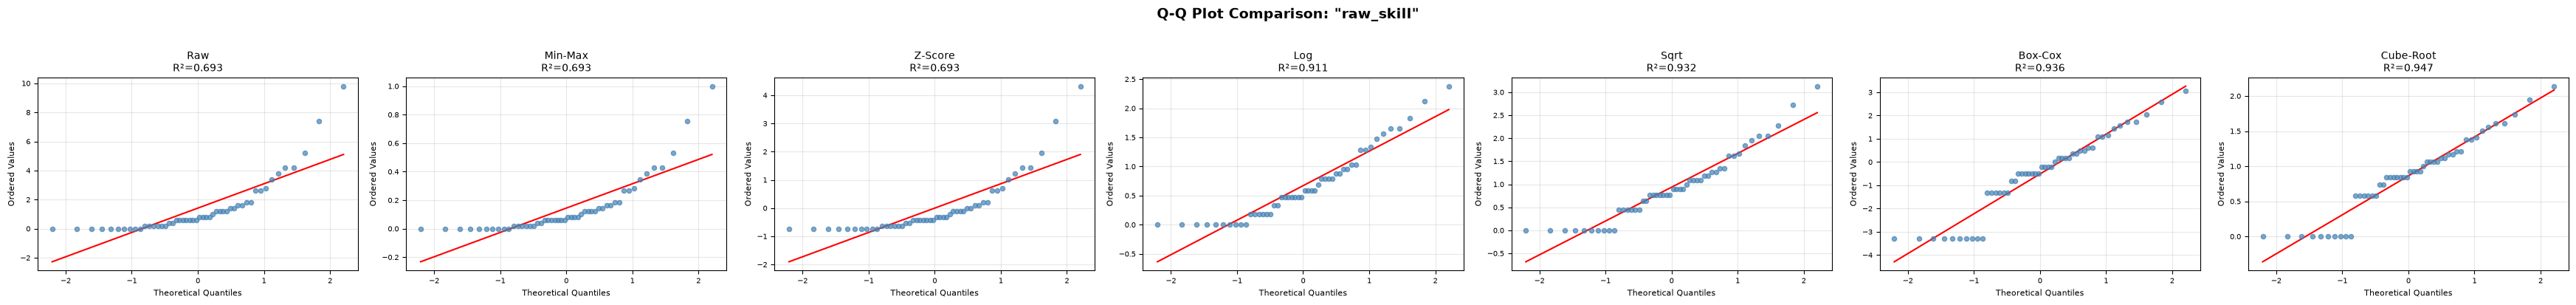

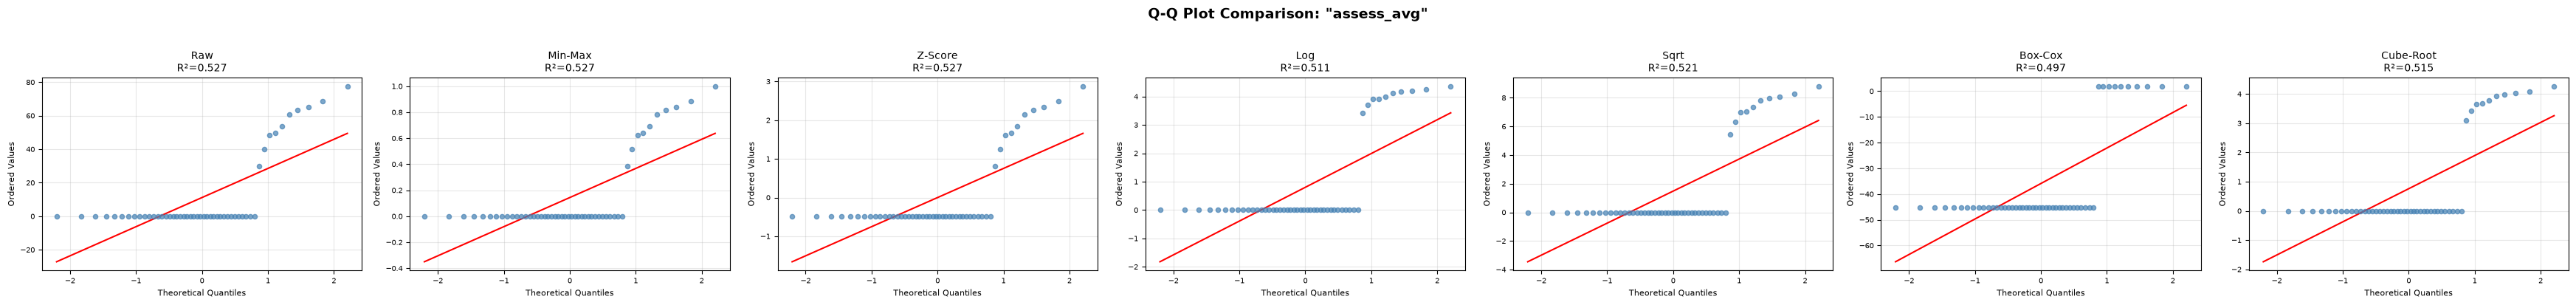

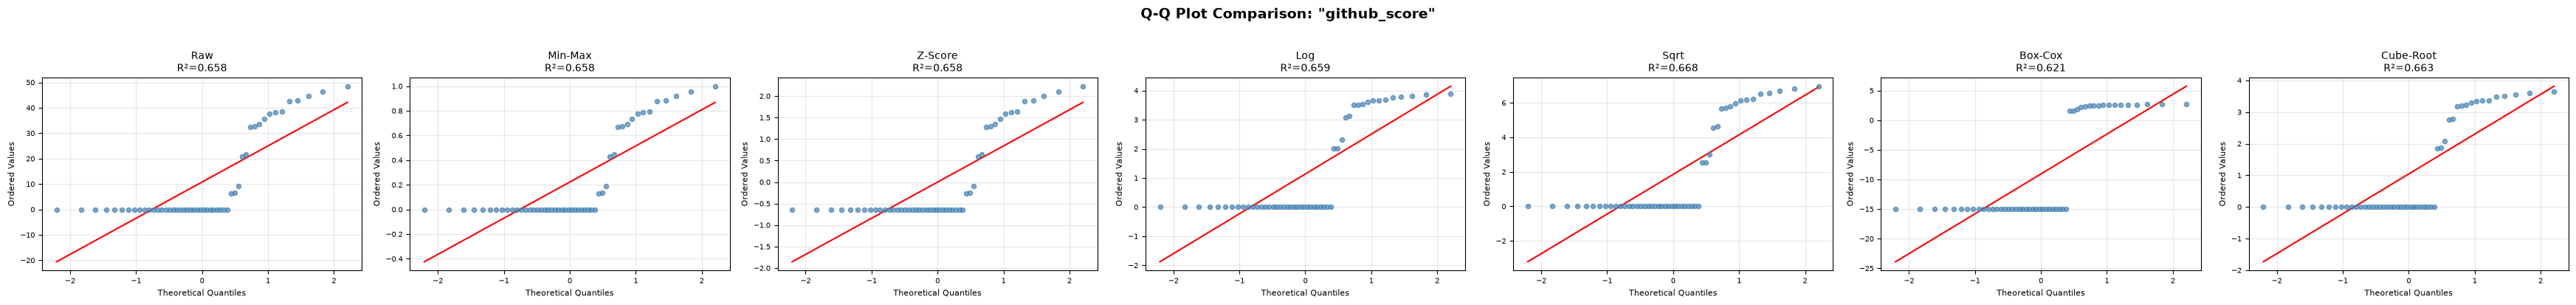

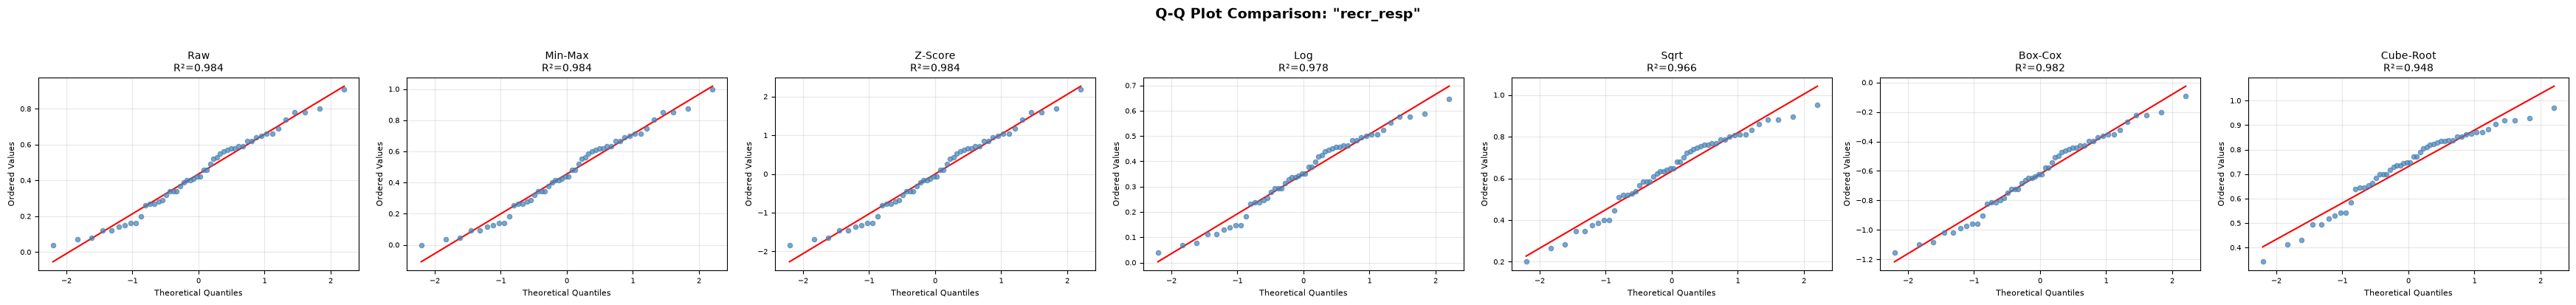

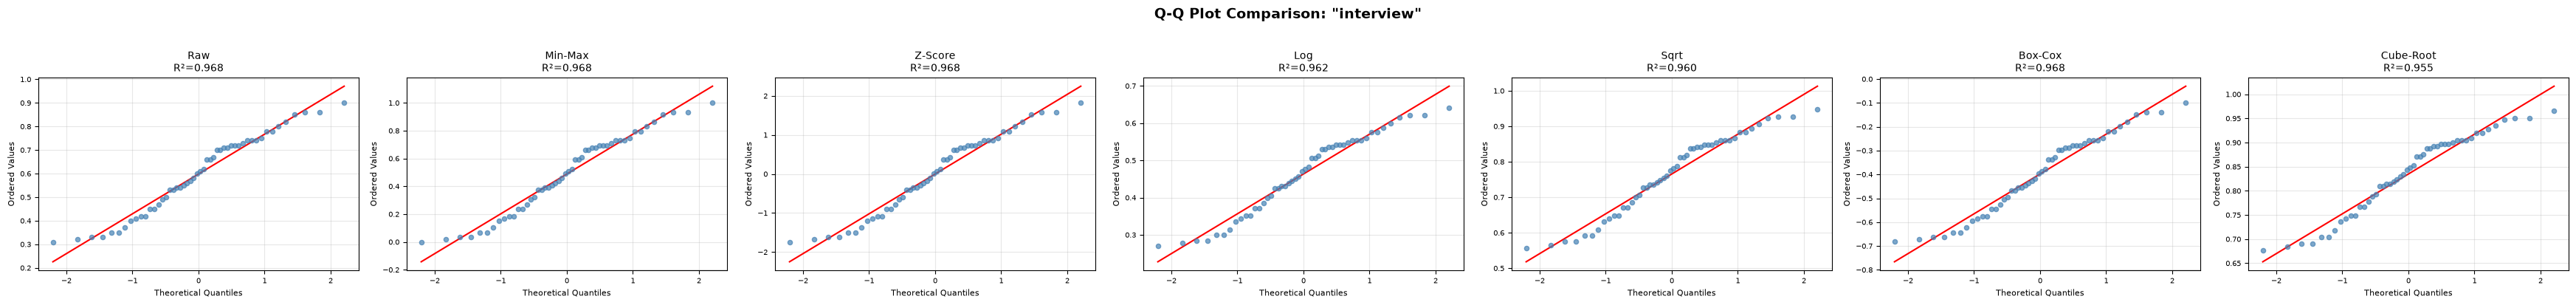

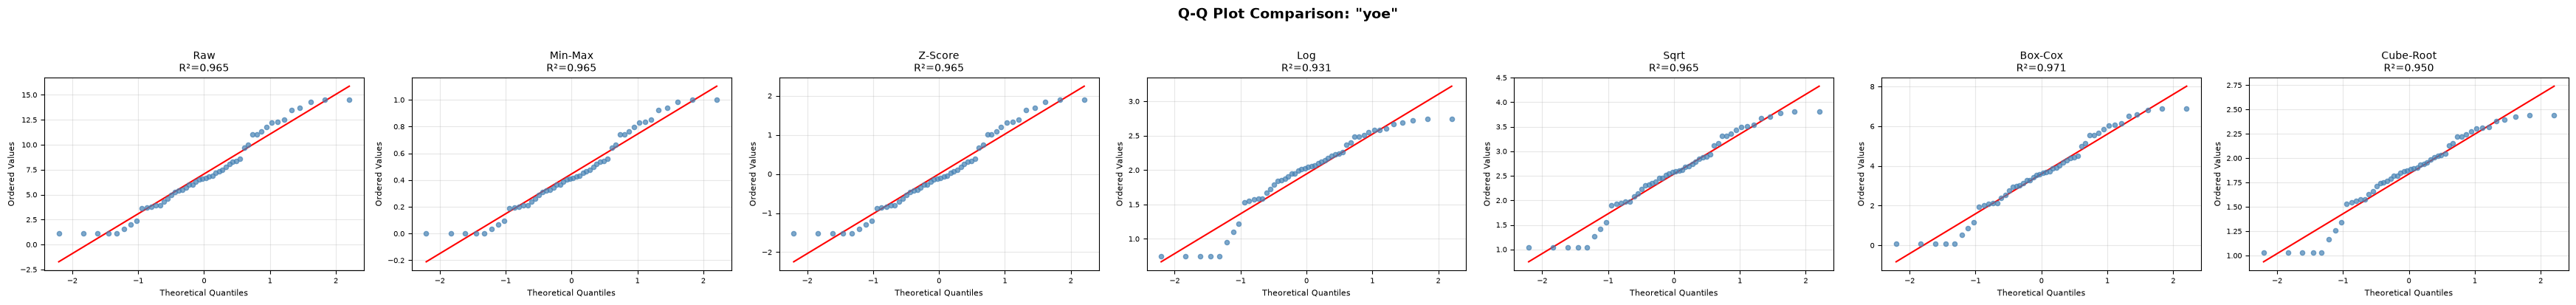

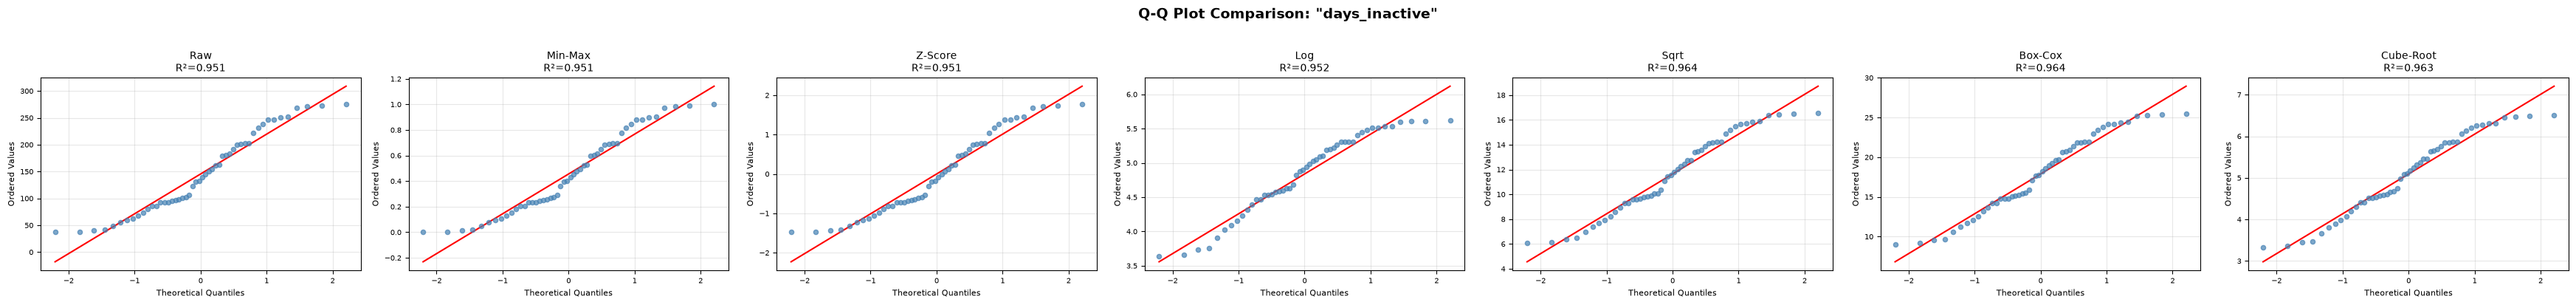

In [8]:
import matplotlib.pyplot as plt
import scipy.stats as stats

METHODS = list(scaled.keys())
N_METHODS = len(METHODS)

for feat in FEATURES:
    fig, axes = plt.subplots(1, N_METHODS, figsize=(5 * N_METHODS, 4))
    fig.suptitle(f'Q-Q Plot Comparison: "{feat}"', fontsize=14, fontweight='bold', y=1.02)

    for ax, method in zip(axes, METHODS):
        data = scaled[method][feat].dropna()

        # Draw the Q-Q plot using scipy
        # probplot returns (theoretical_quantiles, ordered_values) + fit line
        (osm, osr), (slope, intercept, r_value) = stats.probplot(data, dist='norm')

        ax.scatter(osm, osr, alpha=0.7, s=20, color='steelblue', zorder=3)
        ax.plot([min(osm), max(osm)],
                [slope * min(osm) + intercept, slope * max(osm) + intercept],
                color='red', linewidth=1.5, label=f'R²={r_value**2:.3f}')

        ax.set_title(f'{method}\nR²={r_value**2:.3f}', fontsize=10)
        ax.set_xlabel('Theoretical Quantiles', fontsize=8)
        ax.set_ylabel('Ordered Values', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=7)

    plt.tight_layout()
    plt.show()
    print()

## Cell 4: Normality Score — Pick the Winner Per Feature

**What**: Use the **Shapiro-Wilk test** to numerically measure how normal each scaled
version of each feature is. A higher p-value means MORE normal.

**Shapiro-Wilk test**:
- W-statistic close to 1.0 = very normal
- p-value > 0.05 = we cannot reject normality (it IS normal)
- p-value < 0.05 = NOT normal

This gives us a data-driven answer to "which scaling is best for each feature?"

In [9]:
from scipy.stats import shapiro

# Build a table: rows = features, columns = scaling methods
# Value = Shapiro-Wilk W statistic (closer to 1.0 = more normal)
results = []
winners = {}

for feat in FEATURES:
    row = {'feature': feat}
    best_w    = -1
    best_meth = None

    for method in METHODS:
        data = scaled[method][feat].dropna()
        # Shapiro-Wilk requires n < 5000. We have 50 so we're fine.
        w_stat, p_val = shapiro(data)
        row[method] = round(w_stat, 4)
        if w_stat > best_w:
            best_w    = w_stat
            best_meth = method

    row['🏆 Best Scaling'] = best_meth
    winners[feat] = best_meth
    results.append(row)

result_df = pd.DataFrame(results).set_index('feature')

print("Shapiro-Wilk W-statistic (closer to 1.0 = more normal):")
print(result_df.to_string())

print("\n" + "="*50)
print("🏆 BEST SCALING PER FEATURE:")
print("="*50)
for feat, winner in winners.items():
    print(f"  {feat:<15} → {winner}")

Shapiro-Wilk W-statistic (closer to 1.0 = more normal):
                  Raw  Min-Max  Z-Score     Log    Sqrt  Box-Cox  Cube-Root 🏆 Best Scaling
feature                                                                                   
raw_skill      0.7031   0.7031   0.7031  0.9048  0.9285   0.9271     0.9395      Cube-Root
assess_avg     0.5264   0.5264   0.5264  0.5060  0.5172   0.4906     0.5104            Raw
github_score   0.6490   0.6490   0.6490  0.6461  0.6565   0.6068     0.6505           Sqrt
recr_resp      0.9761   0.9761   0.9761  0.9698  0.9601   0.9749     0.9435            Raw
interview      0.9557   0.9557   0.9557  0.9498  0.9478   0.9559     0.9436        Box-Cox
yoe            0.9524   0.9524   0.9524  0.9192  0.9530   0.9585     0.9386        Box-Cox
days_inactive  0.9360   0.9360   0.9360  0.9392  0.9501   0.9503     0.9496        Box-Cox

🏆 BEST SCALING PER FEATURE:
  raw_skill       → Cube-Root
  assess_avg      → Raw
  github_score    → Sqrt
  recr_resp      

## Cell 5: Apply Best Scaling Per Feature

**What**: Now that we know the best scaling for each feature, apply it and build
our final feature matrix — one scaling per feature, whichever won in Cell 4.

**This is the feature matrix we will pass into our entropy-weighted scoring pipeline.**

In [10]:
# Build a final DataFrame using the best scaling per feature
best_scaled = pd.DataFrame()
best_scaled['candidate_id'] = df['candidate_id']

for feat in FEATURES:
    best_method = winners[feat]
    best_scaled[feat] = scaled[best_method][feat].values

print("✅ Final feature matrix (mixed best scalings per feature):")
print(best_scaled[FEATURES].describe().round(4))

print("\nScaling method chosen for each feature:")
for feat in FEATURES:
    print(f"  {feat:<15} → {winners[feat]}")

✅ Final feature matrix (mixed best scalings per feature):
       raw_skill  assess_avg  github_score  recr_resp  interview      yoe  \
count    50.0000     50.0000       50.0000    50.0000    50.0000  50.0000   
mean      0.8626     11.1470        1.8516     0.4358    -0.3981   3.5950   
std       0.5555     23.3331        2.7370     0.2185     0.1654   1.9835   
min       0.0000      0.0000        0.0000     0.0400    -0.6820   0.0992   
25%       0.5848      0.0000        0.0000     0.2725    -0.5400   2.2010   
50%       0.8859      0.0000        0.0000     0.4200    -0.3921   3.6190   
75%       1.1696      0.0000        4.6367     0.5900    -0.2706   5.0982   
max       2.1400     77.6000        6.9642     0.9100    -0.0989   6.8828   

       days_inactive  
count        50.0000  
mean         17.8876  
std           4.9764  
min           9.0409  
25%          14.3544  
50%          17.9861  
75%          21.9028  
max          25.5029  

Scaling method chosen for each feature:


## Cell 6: Distribution Histograms Before vs After Best Scaling

**What**: For each feature, plot two histograms side by side:
- LEFT: Raw (unscaled) distribution
- RIGHT: Best-scaled distribution

**This is your visual proof** that the scaling actually fixed the skewness.

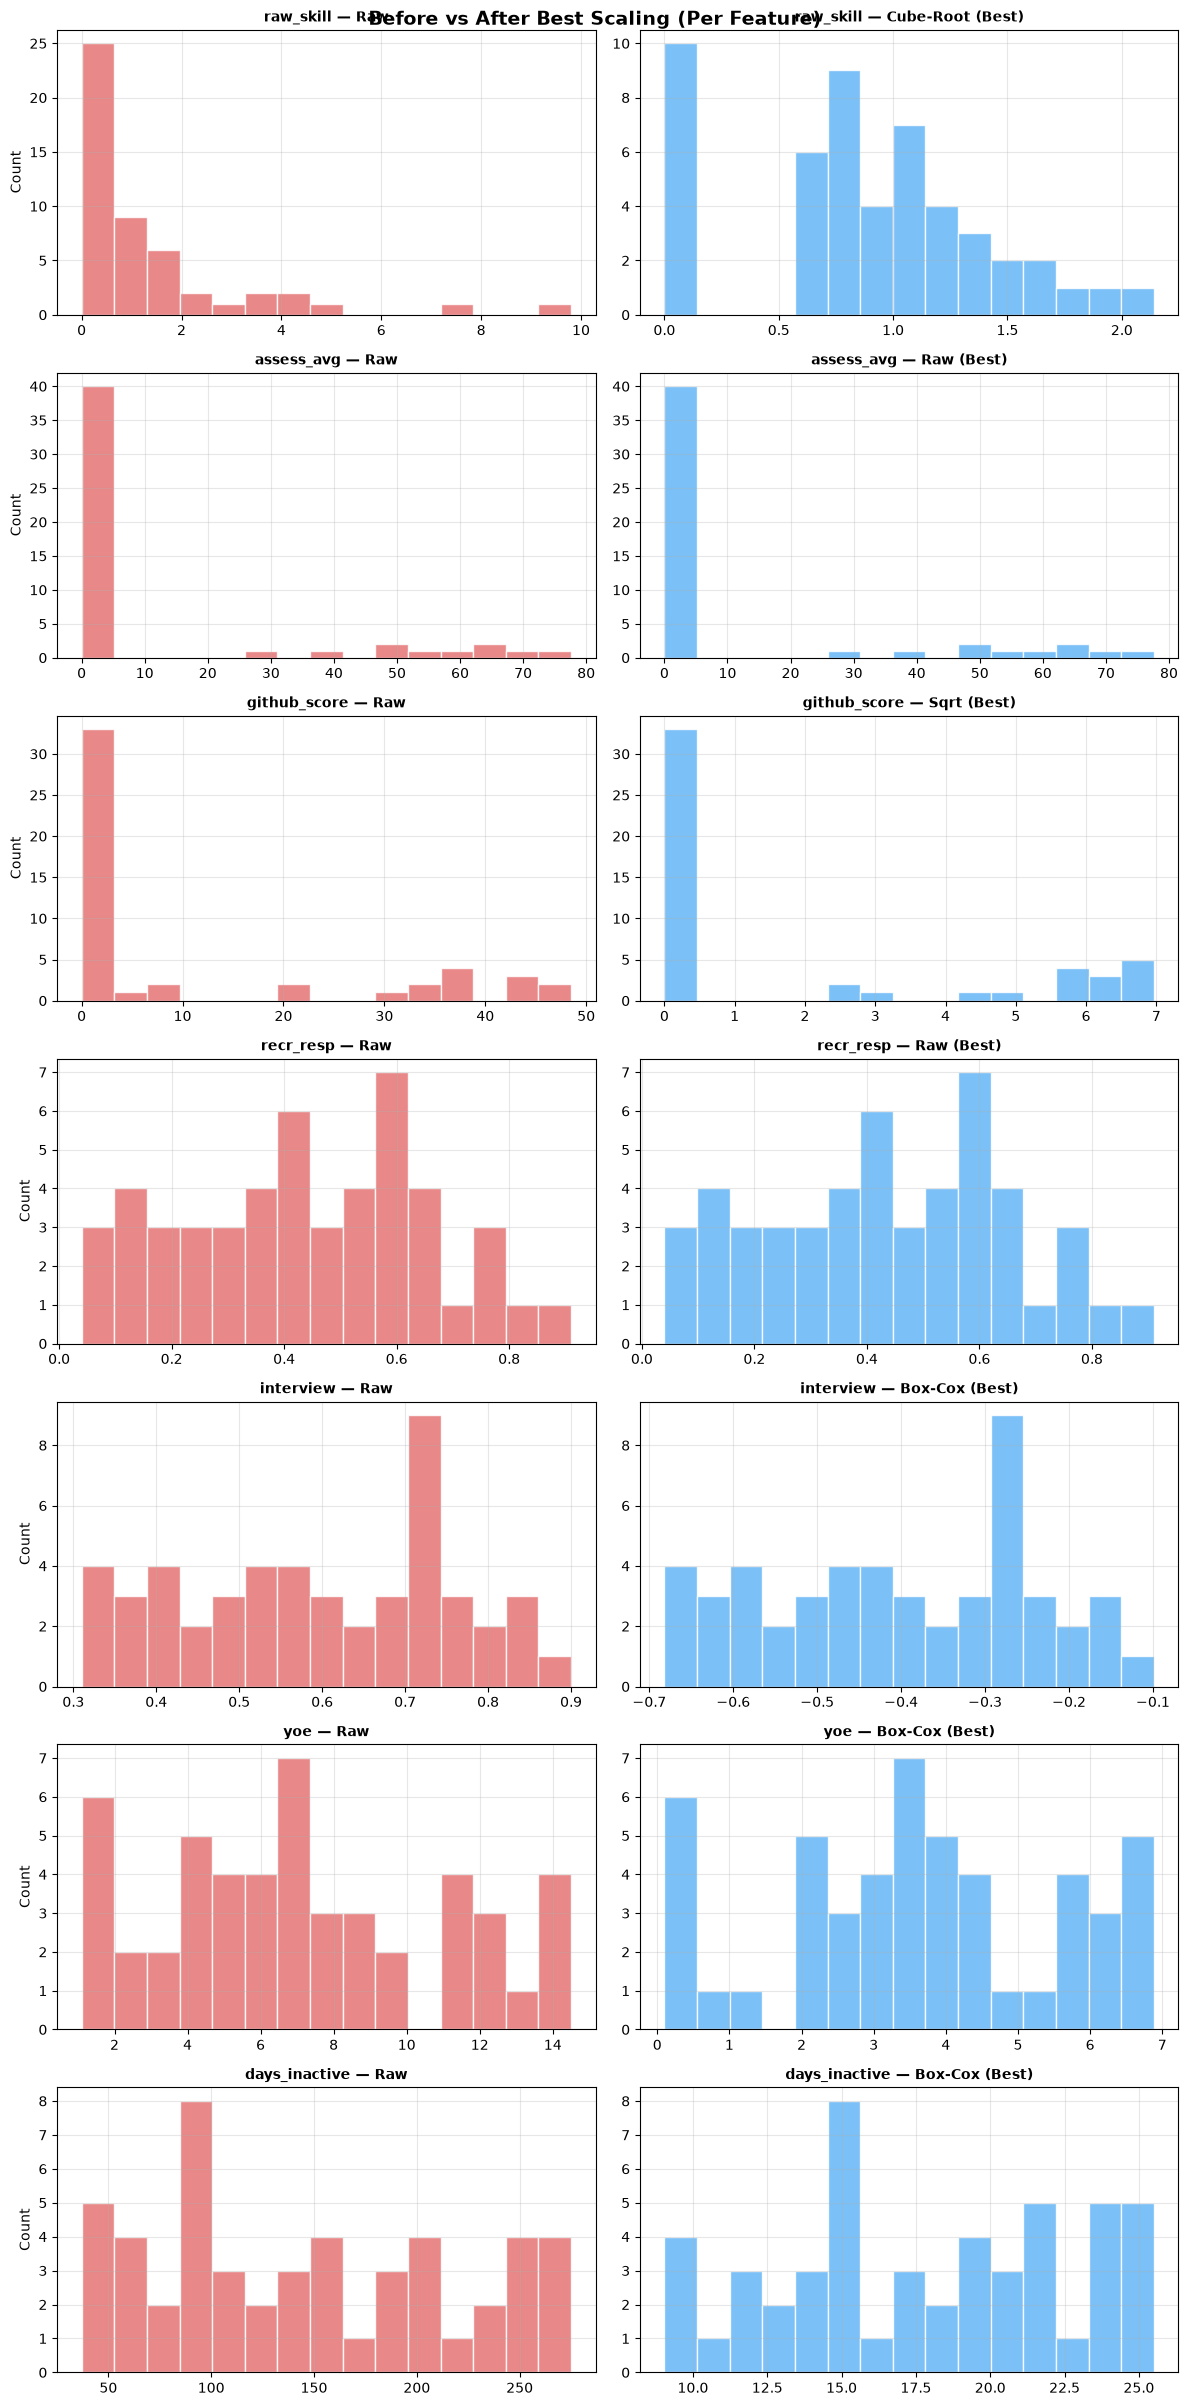

In [11]:
fig, axes = plt.subplots(len(FEATURES), 2,
                          figsize=(12, 3.5 * len(FEATURES)))
fig.suptitle('Before vs After Best Scaling (Per Feature)', fontsize=14, fontweight='bold')

for i, feat in enumerate(FEATURES):
    best_method = winners[feat]

    # LEFT: Raw
    ax_raw = axes[i][0]
    ax_raw.hist(df[feat], bins=15, color='#e57373', edgecolor='white', alpha=0.85)
    ax_raw.set_title(f'{feat} — Raw', fontsize=10, fontweight='bold')
    ax_raw.set_ylabel('Count')
    ax_raw.grid(True, alpha=0.3)

    # RIGHT: Best scaled
    ax_sc = axes[i][1]
    ax_sc.hist(scaled[best_method][feat], bins=15,
               color='#64b5f6', edgecolor='white', alpha=0.85)
    ax_sc.set_title(f'{feat} — {best_method} (Best)', fontsize=10, fontweight='bold')
    ax_sc.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Cell 7: Summary — Interpretation Guide

**Read this after running all cells above.**

Based on the Q-Q plots and Shapiro-Wilk test, here is how to interpret the results:

### Why does this matter for our scoring system?

Most scoring algorithms (percentile rank, weighted sum) work best when the underlying
features are approximately normally distributed.
- If `github_score` is heavily right-skewed (many people at 0, a few at 90+),
  the raw values give unfair weight to outliers.
- After **log scaling**, the distribution spreads out more evenly,
  so the scoring treats differences between 0→10 the same as 80→90.

### Expected findings based on domain knowledge:
| Feature | Expected Skew | Expected Best Scaling |
|---------|-------------|---------------------|
| `raw_skill` | Right-skewed (most have few AI skills) | Log or Box-Cox |
| `assess_avg` | Roughly normal | Z-Score or Min-Max |
| `github_score` | Extreme right skew (most = 0) | Log |
| `recr_resp` | Roughly uniform | Min-Max or Z-Score |
| `interview` | Roughly uniform | Min-Max |
| `yoe` | Right-skewed (many juniors) | Sqrt or Log |
| `days_inactive` | Right-skewed | Log or Box-Cox |

The actual results from your dataset may differ — the Shapiro-Wilk test above
will tell you the truth!